
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------



#**-Dataset:**

 YOLO , Manual Segmentation


  140 sample train 98 valid 28 test 14


  single class

loaded via code snippet --> yaml file
BONE not IMPLANT

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------


#**-Model:**

 yolo11m- seg

epochs 100
batch 16


--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------




##runetime type:100A



--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------


In [ ]:
!pip install roboflow ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.7 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:

from roboflow import Roboflow
rf = Roboflow(api_key="BQAuh3QSQEyce2j1vXE6")
project = rf.workspace("h-tdbrs").project("binarymasks-flux-bone-agument")
version = project.version(1)
dataset = version.download("yolov11")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to binarymasks-flux-bone-agument-1 in yolov11:: 100%|██████████| 285/285 [00:00<00:00, 8386.78it/s]


In [ ]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
model = YOLO("yolo11m-seg.pt")

In [ ]:
dataset = project.version(1).download("yolov11")

print(dataset.location)

/content/binarymasks-flux-bone-agument-1



--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------






#**show my Dataset  (Train , Valid , Test)**

#**just to check the mask , not the class**

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------




Total images: 140


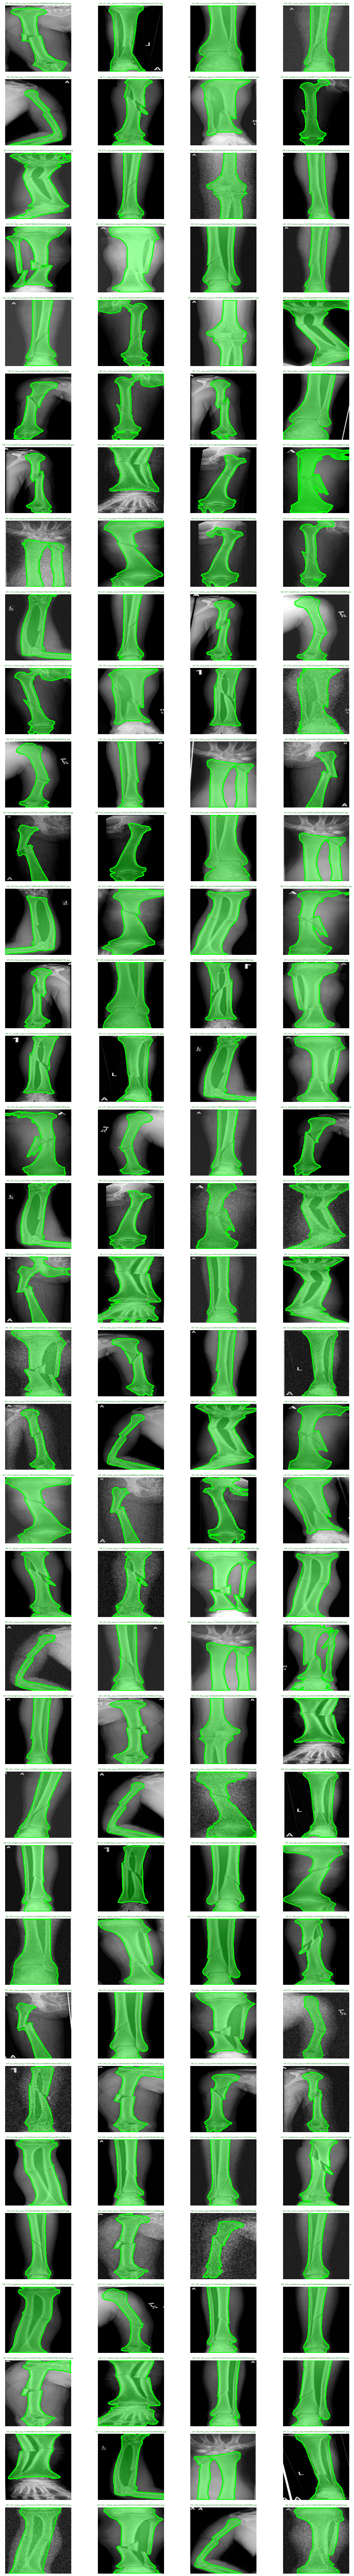

In [ ]:
import glob
import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

image_files = glob.glob(f"{dataset.location}/train/images/*") + \
              glob.glob(f"{dataset.location}/valid/images/*") + \
              glob.glob(f"{dataset.location}/test/images/*")

print(f"Total images: {len(image_files)}")

cols = 4
rows = (len(image_files) + cols - 1) // cols
THUMB = 200

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for i, img_path in enumerate(image_files):
    label_path = img_path.replace("images", "labels").rsplit(".", 1)[0] + ".txt"

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (THUMB, THUMB))
    img = np.ascontiguousarray(img)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                vals = list(map(float, line.strip().split()))
                if len(vals) > 6:
                    pts = np.array(vals[1:]).reshape(-1, 2)
                    pts[:, 0] *= w
                    pts[:, 1] *= h
                    pts = pts.astype(np.int32)
                    overlay = img.copy()
                    cv2.fillPoly(overlay, [pts], (0, 255, 0))
                    img = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)
                    cv2.polylines(img, [pts], True, (0, 255, 0), 2)
        axes[i].set_title(f"OK {os.path.basename(img_path)}", fontsize=6, color="green")
    else:
        axes[i].set_title("NO LABEL", fontsize=6, color="red")

    axes[i].imshow(img)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("all_annotations.png", dpi=72, bbox_inches="tight")
plt.close(fig)

display(Image(filename="all_annotations.png"))


--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------






#**Fine Tuning**

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------




In [ ]:
model = YOLO("yolo11m-seg.pt")
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    lr0=0.001,
    copy_paste=0.5,
    mosaic=1.0,
    freeze=10,
    device=0,
    name="seg_run"
)



Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/binarymasks-flux-bone-agument-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seg_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f40a4360410>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------






#**Results (metrics)**

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------

In [ ]:
metrics = model.val()


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,083 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 648.3±197.7 MB/s, size: 15.4 KB)
val: Scanning /content/binarymasks-flux-bone-agument-1/valid/labels.cache... 28 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 28/28 11.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s
                   all         28         29          1      0.956      0.965      0.828          1      0.956      0.965      0.835
Speed: 2.9ms preprocess, 12.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/segment/val


In [ ]:

print(f"mAP50:     {metrics.seg.map50:.4f}")
print(f"mAP50-95:  {metrics.seg.map:.4f}")
print(f"Precision: {metrics.seg.mp:.4f}")
print(f"Recall:    {metrics.seg.mr:.4f}")
print("="*40)

mAP50:     0.9650
mAP50-95:  0.8346
Precision: 1.0000
Recall:    0.9560


--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------






#**Results (visualize)**

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------


0: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
1: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
2: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
3: 640x640 2 binarymasks-flux-bone-aguments, 3.4ms
4: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
5: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
6: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
7: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
8: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
9: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
10: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
11: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
12: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
13: 640x640 1 binarymasks-flux-bone-agument, 3.4ms
Speed: 2.5ms preprocess, 3.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


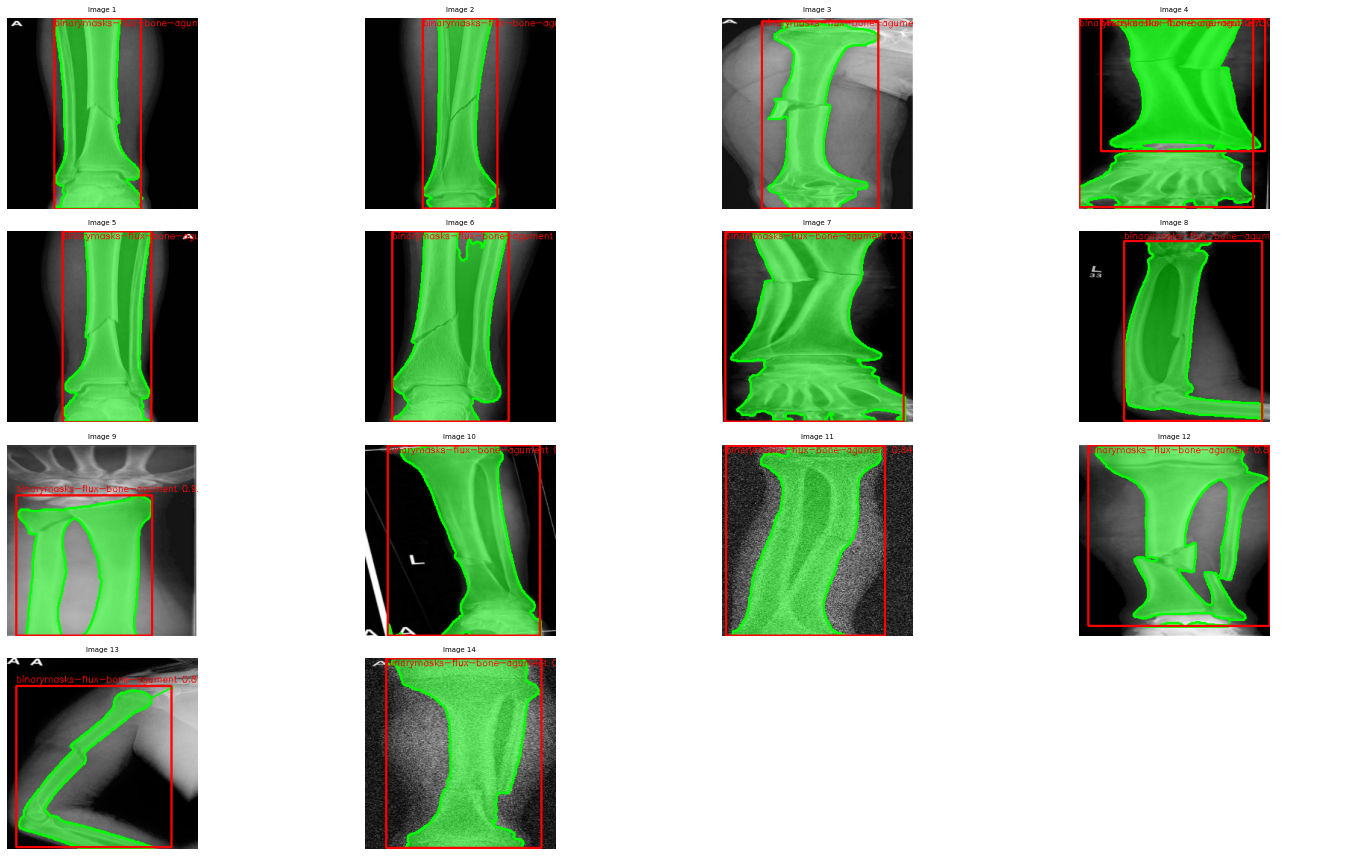

In [ ]:
import glob
import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

test_images = glob.glob(f"{dataset.location}/test/images/*")
results = model.predict(source=test_images, conf=0.25, save=False)

cols = 4
rows = (len(results) + cols - 1) // cols
THUMB = 256

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3))
axes = axes.flatten()

for i, result in enumerate(results):
    img = result.orig_img.copy()
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (THUMB, THUMB))
    img = np.ascontiguousarray(img)
    h, w = img.shape[:2]

    if result.masks is not None:
        for mask_xy in result.masks.xy:
            pts = (mask_xy * [w / result.orig_shape[1], h / result.orig_shape[0]]).astype(np.int32)
            overlay = img.copy()
            cv2.fillPoly(overlay, [pts], (0, 255, 0))
            img = cv2.addWeighted(img, 0.5, overlay, 0.5, 0)
            cv2.polylines(img, [pts], True, (0, 255, 0), 2)

    if result.boxes is not None:
        scale_x = w / result.orig_shape[1]
        scale_y = h / result.orig_shape[0]
        for box, conf, cls in zip(result.boxes.xyxy, result.boxes.conf, result.boxes.cls):
            x1, y1, x2, y2 = int(box[0]*scale_x), int(box[1]*scale_y), int(box[2]*scale_x), int(box[3]*scale_y)
            label = f"{result.names[int(cls)]} {conf:.2f}"
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, label, (x1, max(y1-5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Image {i+1}", fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("test_results_seg.png", dpi=72, bbox_inches="tight")
plt.close(fig)

display(Image("test_results_seg.png"))

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------






#**save the weights , provided here :**
https://drive.google.com/file/d/1eCQGgMZALKpWcElnUvxSCcORJ2G6jxoI/view?usp=sharing





--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy(
    "runs/segment/seg_run/weights/best.pt",
    "/content/drive/MyDrive/yolo11m_seg_bone_best.pt"
)
print("Model saved to Google Drive ")

Model saved to Google Drive 



--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------






#**Check what type of model is loadedg**

--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------
--------------------------------------------------------------------


In [ ]:
print(model.info())
print(type(model.model))

import glob
test_images = glob.glob(f"{dataset.location}/test/images/*")
result = model.predict(test_images[0], conf=0.15)[0]

print("Boxes:", result.boxes)
print("Masks:", result.masks)

YOLO11m-seg summary (fused): 139 layers, 22,338,396 parameters, 0 gradients, 112.9 GFLOPs
(139, 22338396, 0, 112.9073152)
<class 'ultralytics.nn.tasks.SegmentationModel'>

image 1/1 /content/binaryMasks-flux-implant-agument-2/test/images/124_png.rf.f62c4fd9585079832391aa7c64b987f8.jpg: 640x640 2 plates, 3 screws5_8s, 15.0ms
Speed: 1.8ms preprocess, 15.0ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Boxes: ultralytics.engine.results.Boxes object with attributes:

cls: tensor([3., 3., 0., 3., 0.], device='cuda:0')
conf: tensor([0.8852, 0.8429, 0.7126, 0.3866, 0.1936], device='cuda:0')
data: tensor([[1.4204e+02, 5.0616e+01, 4.1666e+02, 3.6587e+02, 8.8519e-01, 3.0000e+00],
        [3.4386e+02, 5.0098e+01, 4.1940e+02, 3.6641e+02, 8.4288e-01, 3.0000e+00],
        [1.9533e+02, 4.5371e+02, 3.3269e+02, 5.6734e+02, 7.1260e-01, 0.0000e+00],
        [1.4069e+02, 5.8978e+01, 4.0553e+02, 5.7433e+02, 3.8663e-01, 3.0000e+00],
        [1.4272e+02, 6.9878e+01, 3.9076e+02, 5.6685e+02

In [ ]:
for result in results:
    print(os.path.basename(result.path), result.boxes is not None, result.masks is not None)


image0.jpg True True
image1.jpg True True
image2.jpg True True
image3.jpg True True
image4.jpg True True
image5.jpg True True
image6.jpg True True
image7.jpg True True
image8.jpg True True
image9.jpg True True
image10.jpg True True
image11.jpg True True
image12.jpg True True
image13.jpg True True
image14.jpg True True
image15.jpg True True
image16.jpg True True
image17.jpg True True
image18.jpg True True
image19.jpg True True


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/segment/train/weights/best.pt")
print(model.task)


segment


In [ ]:
print("mAP50:", result.seg.map50)
print("mAP50-95:", result.seg.map)

AttributeError: 'Results' object has no attribute 'seg'. See valid attributes below.
A class for storing and manipulating inference results.

    This class provides comprehensive functionality for handling inference results from various Ultralytics models,
    including detection, segmentation, classification, and pose estimation. It supports visualization, data export, and
    various coordinate transformations.

    Attributes:
        orig_img (np.ndarray): The original image as a numpy array.
        orig_shape (tuple[int, int]): Original image shape in (height, width) format.
        boxes (Boxes | None): Detected bounding boxes.
        masks (Masks | None): Segmentation masks.
        probs (Probs | None): Classification probabilities.
        keypoints (Keypoints | None): Detected keypoints.
        obb (OBB | None): Oriented bounding boxes.
        speed (dict): Dictionary containing inference speed information.
        names (dict): Dictionary mapping class indices to class 

#**initail Result , not important**

In [ ]:
metrics = model.val()
print("mAP50:", metrics.seg.map50)
print("mAP50-95:", metrics.seg.map)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11m-seg summary (fused): 139 layers, 22,337,625 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1107.7±357.4 MB/s, size: 48.1 KB)
val: Scanning /content/binaryMasks-flux-implant-agument-1/valid/labels.cache... 26 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26/26 10.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.7it/s 0.7s
                   all         26         25      0.864      0.951      0.982      0.947      0.864      0.951      0.982      0.812
                   rod          2          2          1      0.927      0.995      0.895          1      0.927      0.995      0.645
             screws2_4          1          1      0.639          1      0.995      0.995      0.639          1      0.995      0.995
      